In [2]:
%pip install numpy matplotlib pandas scipy astropy


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from scipy.special  import gamma
from astropy import constants as const
from astropy import units as u


In [4]:
data_m82spec = pd.read_csv("m82spec.txt", sep=r"\s+", engine="python",skiprows=1,names=["lambda (micron)","Lnu (Lsun/Hz)","sigmaLnu (Lsun/Hz)"])

In [5]:
data_PAHion_30 = pd.read_csv("PAHion_30_set1.txt", sep=r"\s+", engine="python",skiprows=1,names=["w(micron)", "Q_ext", "Q_abs", "Q_sca", "g=<cos>"])

In [6]:
data_sil_81 = pd.read_csv("Sil_81.txt", sep=r"\s+", engine="python", skiprows=1,names=["w(micron)","Q_abs","Q_sca","g=<cos>"])

### EDA

In [7]:
data_sil_81.head()

,w(micron),Q_abs,Q_sca,g=<cos>
0,1000.0,1.371000e-07,2.530000e-21,0.0
1,944.1,1.538000e-07,3.185000e-21,0.0
2,891.3,1.726000e-07,4.010000e-21,0.0
3,841.4,1.936000e-07,5.048000e-21,0.0
4,794.3,2.173000e-07,6.355000e-21,0.0


In [8]:
data_sil_81.shape

(241, 4)

In [9]:
data_PAHion_30.shape

(1201, 5)

In [10]:
data_m82spec.shape

(169, 3)

In [11]:
data_m82spec

,lambda (micron),Lnu (Lsun/Hz),sigmaLnu (Lsun/Hz)
0,0.2460,1.845000e-07,2.768000e-08
1,0.2980,5.870000e-07,8.806000e-08
2,0.3320,1.053000e-06,1.580000e-07
3,0.3600,1.731000e-06,9.720000e-08
4,0.3652,1.302000e-06,2.599000e-07
...,...,...,...
164,12240.0000,5.022000e-06,2.511000e-07
165,20120.0000,7.301000e-06,3.650000e-07
166,20390.0000,7.554000e-06,3.777000e-07
167,28020.0000,9.390000e-06,4.695000e-07


In [12]:
data_m82spec["lambda (micron)"]

0          0.2460
1          0.2980
2          0.3320
3          0.3600
4          0.3652
          ...    
164    12240.0000
165    20120.0000
166    20390.0000
167    28020.0000
168    59960.0000
Name: lambda (micron), Length: 169, dtype: float64

In [13]:
Lambda= data_m82spec["lambda (micron)"]
Lnu = data_m82spec["Lnu (Lsun/Hz)"]
sigmaLnu = data_m82spec["sigmaLnu (Lsun/Hz)"]
nu = 2.998e8/(Lambda*1e-6)

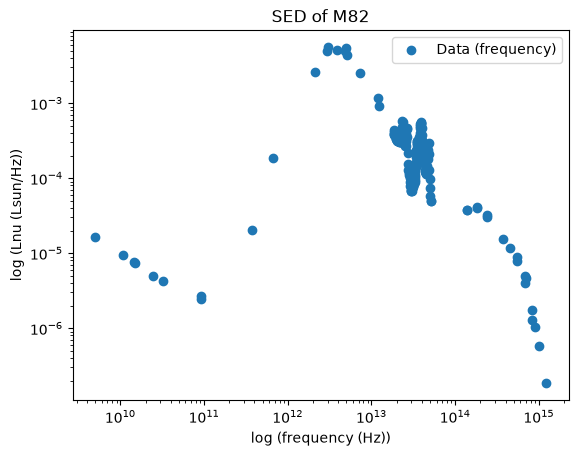

In [14]:
plt.scatter(nu,Lnu, label="Data (frequency)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("log (frequency (Hz))")
plt.ylabel("log (Lnu (Lsun/Hz))")
plt.title("SED of M82")
plt.legend()
plt.show()

This is the first plot of the SED of M82 using the data points

In [15]:
data_PAHion_30.head()

,w(micron),Q_ext,Q_abs,Q_sca,g=<cos>
0,1000.0,2.169000e-09,2.169000e-09,6.536000e-23,0.0
1,988.6,2.219000e-09,2.219000e-09,6.844000e-23,0.0
2,977.2,2.270000e-09,2.270000e-09,7.166000e-23,0.0
3,966.1,2.322000e-09,2.322000e-09,7.504000e-23,0.0
4,955.0,2.375000e-09,2.375000e-09,7.857000e-23,0.0


In [16]:
data_PAHion_30.dtypes

w(micron)    float64
Q_ext        float64
Q_abs        float64
Q_sca        float64
g=<cos>      float64
dtype: object

In [17]:
data_PAHion_30.columns

Index(['w(micron)', 'Q_ext', 'Q_abs', 'Q_sca', 'g=<cos>'], dtype='str')

In [18]:
data_PAHion_30.head()
#3.548E-04 = radius(micron) ionized PAH/graphitic solid 

,w(micron),Q_ext,Q_abs,Q_sca,g=<cos>
0,1000.0,2.169000e-09,2.169000e-09,6.536000e-23,0.0
1,988.6,2.219000e-09,2.219000e-09,6.844000e-23,0.0
2,977.2,2.270000e-09,2.270000e-09,7.166000e-23,0.0
3,966.1,2.322000e-09,2.322000e-09,7.504000e-23,0.0
4,955.0,2.375000e-09,2.375000e-09,7.857000e-23,0.0


In [19]:
data_sil_81.head()

,w(micron),Q_abs,Q_sca,g=<cos>
0,1000.0,1.371000e-07,2.530000e-21,0.0
1,944.1,1.538000e-07,3.185000e-21,0.0
2,891.3,1.726000e-07,4.010000e-21,0.0
3,841.4,1.936000e-07,5.048000e-21,0.0
4,794.3,2.173000e-07,6.355000e-21,0.0


In [20]:
def absorption_opacity(data, grain_radius_um, rho_gcm3):
    
    lambda_um = data['w(micron)']
    Qabs      = data['Q_abs']


    a_cm = grain_radius_um * 1e-4          
    kappa = (3.0 * Qabs) / (4.0 * a_cm * rho_gcm3)   

    nu = 2.998e8 / (lambda_um * 1e-6)   
    return nu, kappa



nu_pah, kappa_pah = absorption_opacity(data_PAHion_30, grain_radius_um=0.0005, rho_gcm3=2.2)
nu_sil, kappa_sil = absorption_opacity(data_sil_81, grain_radius_um=0.1, rho_gcm3=3.5)

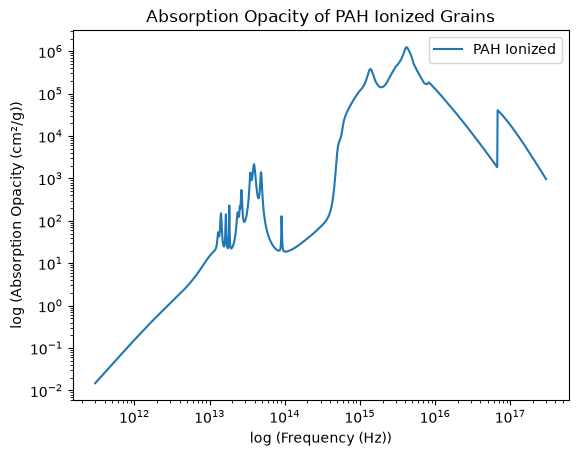

In [21]:
plt.plot(nu_pah, kappa_pah, label="PAH Ionized")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("log (Frequency (Hz))")
plt.ylabel("log (Absorption Opacity (cm²/g))")
plt.title("Absorption Opacity of PAH Ionized Grains")
plt.legend()
plt.show()

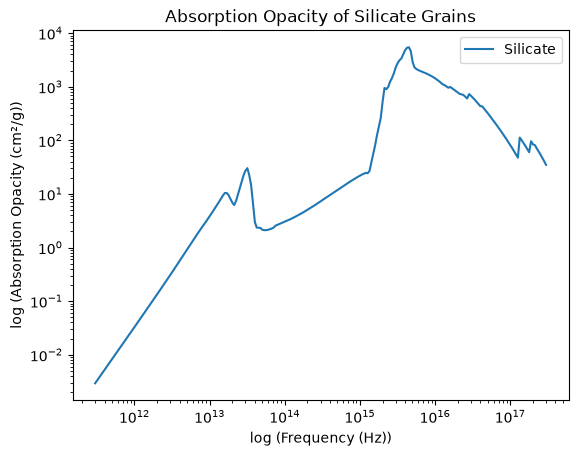

In [22]:
plt.plot(nu_sil, kappa_sil, label="Silicate")
plt.xscale("log")
plt.yscale("log")                               
plt.xlabel("log (Frequency (Hz))")
plt.ylabel("log (Absorption Opacity (cm²/g))")
plt.title("Absorption Opacity of Silicate Grains")
plt.legend()
plt.show()

In [23]:
nu_plot = np.logspace(np.log10(min(nu)), np.log10(max(nu)), 5000)

### Dust Model

In [24]:
def planck_nu(nu, T):
    h = const.h.value
    k = const.k_B.value
    c = const.c.value

    return (2*h*nu**3 / c**2) / (np.exp(h*nu/(k*T)) - 1)

In [25]:
def absorption_opacity(data, grain_radius_um, rho_gcm3):
    lambda_um = data['w(micron)'].values
    Qabs      = data['Q_abs'].values
    a_cm = grain_radius_um * 1e-4          
    kappa = (3.0 * Qabs) / (4.0 * a_cm * rho_gcm3)   
    nu = const.c.value / (lambda_um * 1e-6)
    return nu, kappa


In [26]:
kappa_sil_plot = np.interp(nu_plot, nu_sil, kappa_sil)
kappa_pah_plot = np.interp(nu_plot, nu_pah, kappa_pah)

T_sil = 37.5
A_sil = 1.679e+12

T_pah = 402.4
A_pah = 4.8e+4

dust_model_sil = A_sil * kappa_sil_plot * planck_nu(nu_plot, T_sil)
dust_model_pah = A_pah * kappa_pah_plot * planck_nu(nu_plot, T_pah)


/tmp/ipykernel_29721/3844236333.py:6: RuntimeWarning: overflow encountered in exp
  return (2*h*nu**3 / c**2) / (np.exp(h*nu/(k*T)) - 1)


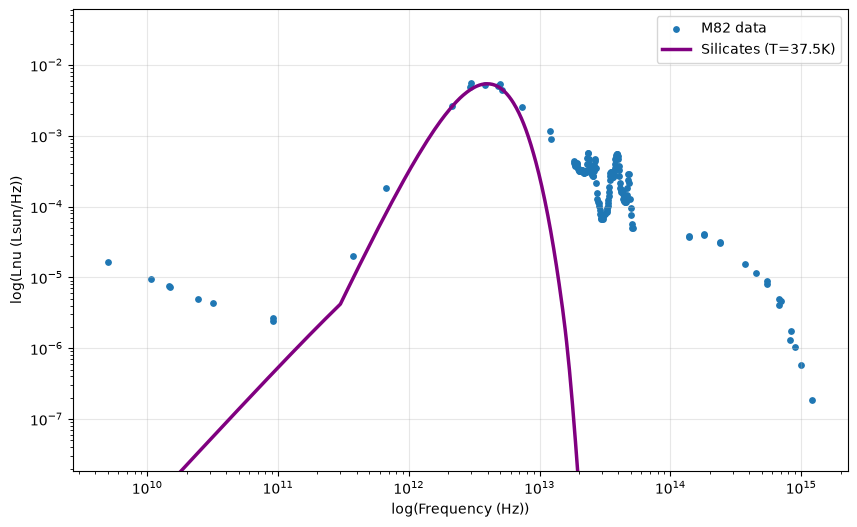

In [27]:
plt.figure(figsize=(10,6))
plt.scatter(nu, Lnu,s=15,label='M82 data')
plt.plot(nu_plot, dust_model_sil, lw=2.5,color='purple', label=f'Silicates (T={T_sil}K)')
plt.xscale('log')
plt.yscale('log')
plt.ylim(min(Lnu)*0.1, max(Lnu)*11)
plt.xlabel('log(Frequency (Hz))')
plt.ylabel('log(Lnu (Lsun/Hz))')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

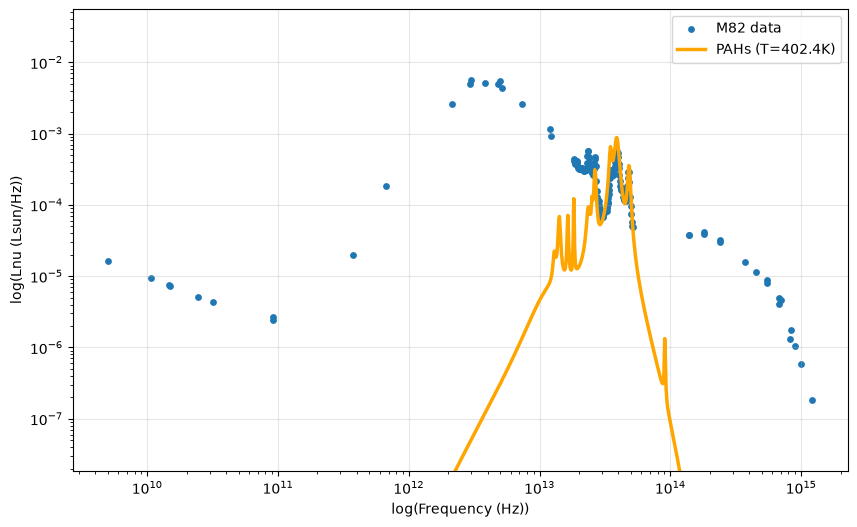

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(nu, Lnu, s=15, label='M82 data')
plt.plot(nu_plot, dust_model_pah, lw=2.5,color="orange", label=f'PAHs (T={T_pah}K)')
plt.xscale('log')
plt.yscale('log')
plt.ylim(min(Lnu)*0.1, max(Lnu)*10)
plt.xlabel('log(Frequency (Hz))')
plt.ylabel('log(Lnu (Lsun/Hz))')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Thermal Bremsstruhlung(Free-Free) Model

In [29]:
def Free_Free(A_ff,Z,ne,ni,Te,nu,g_ff):
    h = const.h.value
    k = const.k_B.value
    return A_ff*6.8e-38*Z**2*ne*ni*Te**-0.5*np.exp(-h*nu/(k*Te))*g_ff

In [30]:
ff_model = Free_Free(A_ff=1.582e+15,Z=1, ne=1e10, ni=1e10, Te=9242.5, nu=nu_plot, g_ff=1)

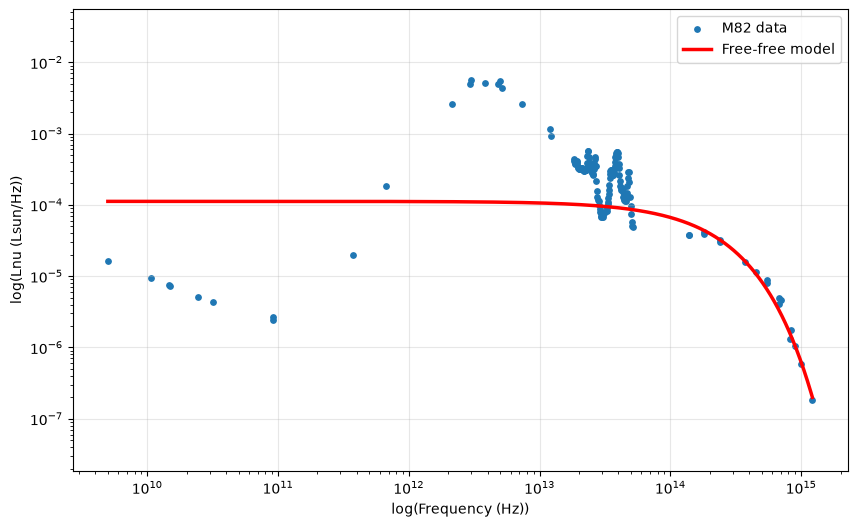

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(nu, Lnu, s=15, label='M82 data')
plt.plot(nu_plot,ff_model, lw=2.5, color='red', label='Free-free model')
plt.xscale('log')
plt.yscale('log')
plt.ylim(min(Lnu)*0.1, max(Lnu)*10)
plt.xlabel('log(Frequency (Hz))')
plt.ylabel('log(Lnu (Lsun/Hz))')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("free_free_model.png")
plt.show()


In [32]:
print("nu_ff",nu[18])
print("Lnu_ff", Lnu[5])

nu_ff 51671837297483.63
Lnu_ff 4.624e-06


In [33]:
print(np.min(Lnu), np.max(Lnu))
print(np.min(ff_model), np.max(ff_model))


1.845e-07 0.005578
1.997656321350756e-07 0.00011189466662408


In [34]:
print(nu.min())
print(nu.max())

5000000000.0
1218699186991870.0


### Synchrotron Emission Model

In [35]:
def sync(C,B,alpha,nu,a):
    q = const.e.value
    c = const.c.value
    m_e = const.m_e.value

    return ((np.sqrt(3)*q**3*C*B*np.sin(alpha))/(4*np.pi*m_e*c**2*(a+1)))*(gamma((a/2)+(11/6)))*(gamma((a/2)+(1/6)))*((m_e*c*2*np.pi*nu)/(3*q*B*np.sin(alpha)))**-a

In [36]:
sync_model = sync(C=1.6e+57,B=1e-8,alpha=np.pi/2,nu=nu_plot,a=0.651)

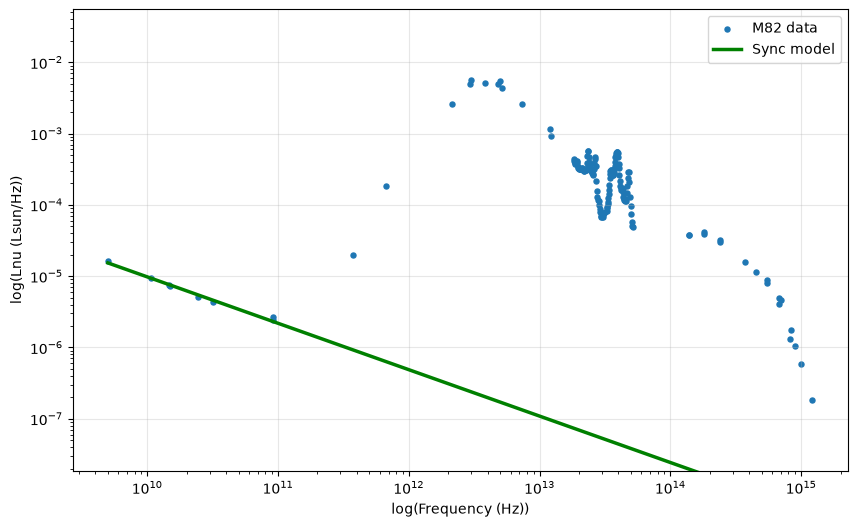

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(nu, Lnu, s=13, label='M82 data')
plt.plot(nu_plot, sync_model, lw=2.5, color='green', label='Sync model')
plt.xscale('log')
plt.yscale('log')
plt.ylim(min(Lnu)*0.1, max(Lnu)*10)
plt.xlabel('log(Frequency (Hz))')
plt.ylabel('log(Lnu (Lsun/Hz))')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("sync_model.png")
plt.show()


In [38]:
print(np.min(sync_model))
print(np.max(sync_model))

4.774541815707465e-09
1.5339841204212888e-05


In [39]:
print("nu:", nu[168])
print("Lnu:", Lnu[168])

nu: 5000000000.0
Lnu: 1.65e-05


In [40]:
print("nu:", nu[163])
print("Lnu:",Lnu[163])

nu: 31999146120.18359
Lnu: 4.305e-06


In [41]:
a = -np.divide(np.log(Lnu[163])-np.log(Lnu[168]),np.log(nu[163]) - np.log(nu[168]))
print("a =", a)

a = 0.7238075805470533


### $\chi$^2  - fitting

#### $\chi$^2 dust model

In [42]:
dust_mask = (nu >= 1e11) & (nu <= 8e13)

nu_dust = nu[dust_mask]
Lnu_dust = Lnu[dust_mask]
sigma_dust = sigmaLnu[dust_mask]
print("Number of dust points =", len(nu_dust))
print("nu range =", nu_dust.min(), nu_dust.max())
print("Lnu range =", Lnu_dust.min(), Lnu_dust.max())

Number of dust points = 143
nu range = 374750000000.00006 51671837297483.63
Lnu range = 2.01e-05 0.005578


In [43]:
def Chi_square_sil(params):

    A_scale, T_scale = params

    A_sil = A_scale * 1e12
    T_sil = T_scale * 10

    kappa_sil_dust = np.interp(
        nu_dust,
        nu_sil,
        kappa_sil
    )

    predictions = (
        A_sil
        * kappa_sil_dust
        * planck_nu(nu_dust, T_sil)
    )

    residuals = Lnu_dust - predictions

    return np.sum((residuals / sigma_dust)**2)

initial_guess_sil = [1.9, 3.8]

result_sil = minimize(
    Chi_square_sil,
    initial_guess_sil,
    method='L-BFGS-B',
    bounds=[
        (0.001, 100),
        (1, 20)
    ]
)

A_sil_best = result_sil.x[0] * 1e12
T_sil_best = result_sil.x[1] * 10

chi2_sil = result_sil.fun
dof_sil = len(nu_dust) - 2
reduced_chi2_sil = chi2_sil / dof_sil

print("Initial A_sil =", 1.9e12)
print("Initial T_sil =", 38)

print("Best A_sil =", A_sil_best)
print("Best T_sil =", T_sil_best)

print("Initial chi-square =", Chi_square_sil(initial_guess_sil))
print("Minimum chi-square =", chi2_sil)

print("Number of points =", len(nu_dust))
print("Degrees of freedom =", dof_sil)
print("Reduced chi-square =", reduced_chi2_sil)


Initial A_sil = 1900000000000.0
Initial T_sil = 38
Best A_sil = 787706327272.94
Best T_sil = 44.575065884788074
Initial chi-square = 52991.56032105548
Minimum chi-square = 52828.98024488862
Number of points = 143
Degrees of freedom = 141
Reduced chi-square = 374.6736187580753


In [44]:
def Chi_square_pah(params):

    A_scale, T_scale = params

    A_pah = A_scale * 1e4
    T_pah = T_scale * 100

    kappa_pah_dust = np.interp(
        nu_dust,
        nu_pah,
        kappa_pah
    )

    predictions = (
        A_pah
        * kappa_pah_dust
        * planck_nu(nu_dust, T_pah)
    )

    residuals = Lnu_dust - predictions

    return np.sum((residuals / sigma_dust)**2)
initial_guess_pah = [4.8, 4.024]

result_pah = minimize(
    Chi_square_pah,
    initial_guess_pah,
    method='L-BFGS-B',
    bounds=[
        (0.001, 100),
        (1, 10)
    ]
)

A_pah_best = result_pah.x[0] * 1e4
T_pah_best = result_pah.x[1] * 100

chi2_pah = result_pah.fun
dof_pah = len(nu_dust) - 2
reduced_chi2_pah = chi2_pah / dof_pah

print("Initial A_pah =", 4.8e4)
print("Initial T_pah =", 402.4)

print("Best A_pah =", A_pah_best)
print("Best T_pah =", T_pah_best)

print("Initial chi-square =", Chi_square_pah(initial_guess_pah))
print("Minimum chi-square =", chi2_pah)

print("Number of points =", len(nu_dust))
print("Degrees of freedom =", dof_pah)
print("Reduced chi-square =", reduced_chi2_pah)



Initial A_pah = 48000.0
Initial T_pah = 402.4
Best A_pah = 908529.1690477511
Best T_pah = 227.32980581621297
Initial chi-square = 29210.445198790134
Minimum chi-square = 22019.915933347875
Number of points = 143
Degrees of freedom = 141
Reduced chi-square = 156.1696165485665


#### $\chi$^2 thermal bremsstruhlung

In [45]:
ff_mask = (nu >= 9e14) & (nu <= 5e15)

nu_ff = nu[ff_mask]
Lnu_ff = Lnu[ff_mask]
sigma_ff = sigmaLnu[ff_mask]

In [46]:
def Chi_square(params):

    A_scale, T_scale = params

    A_ff = A_scale * 1e14
    Te = T_scale * 1e4

    predictions = Free_Free(
        A_ff=A_ff,
        Z=1,
        ne=1e10,
        ni=1e10,
        Te=Te,
        nu=nu_ff,
        g_ff=1
    )

    residuals = Lnu_ff - predictions

    return np.sum((residuals / sigma_ff)**2)

In [47]:
initial_guess = [12.5, 0.92107938]

result = minimize(
    Chi_square,
    initial_guess,
    method='L-BFGS-B',
    bounds=[
        (0.001, 100),
        (0.01, 10)
    ]
)

A_best = result.x[0] * 1e14
Te_best = result.x[1] * 1e4

print("Initial A_ff =", 12.5e14)
print("Initial Te =", 9.2107938e3)
print("Best A_ff =", A_best)
print("Best Te =", Te_best)
print("Initial chi-square =", Chi_square(initial_guess))
print("Minimum chi-square =", result.fun)
print("Number of points =", len(nu_ff))
print("Degrees of freedom =", len(nu_ff) - 2)
print("Reduced chi-square =", result.fun / (len(nu_ff) - 2))

Initial A_ff = 1250000000000000.0
Initial Te = 9210.7938
Best A_ff = 2071562584349377.5
Best Te = 8716.640298449935
Initial chi-square = 5.503659890394774
Minimum chi-square = 0.007259357068982468
Number of points = 3
Degrees of freedom = 1
Reduced chi-square = 0.007259357068982468


### Total Model

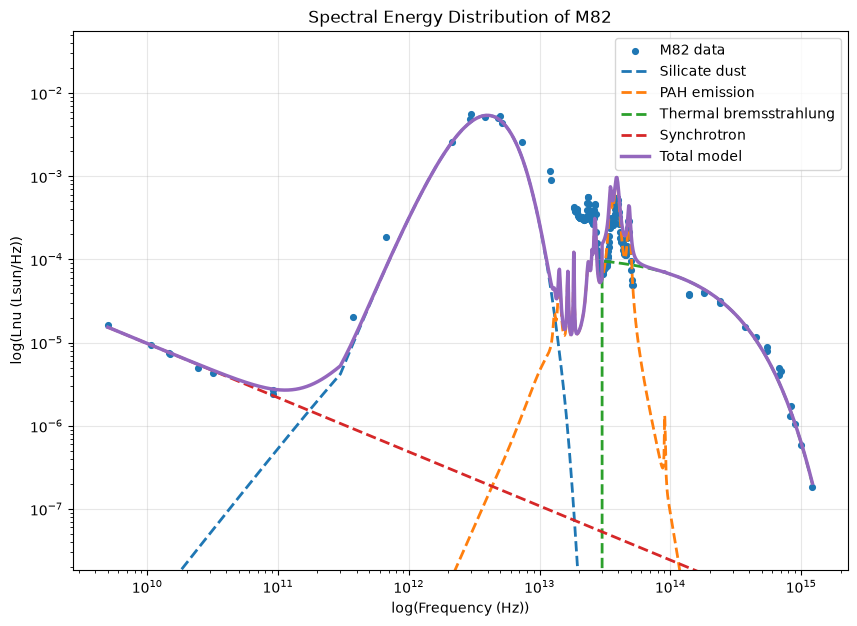

In [51]:
#dust_model_sil[nu_plot < 1e11] = 0
#dust_model_pah[nu_plot < 3e13] = 0
ff_model[nu_plot < 3e13] = 0
#sync_model[nu_plot > 3e11] = 0

dust_model = dust_model_sil + dust_model_pah
total_model = dust_model + ff_model + sync_model

plt.figure(figsize=(10, 7))
plt.scatter(nu, Lnu,s=17,label='M82 data')
plt.plot(nu_plot, dust_model_sil,'--',linewidth=2,label='Silicate dust')
plt.plot(nu_plot, dust_model_pah, '--', linewidth=2,label='PAH emission')
plt.plot( nu_plot, ff_model,'--',linewidth=2,label='Thermal bremsstrahlung')
plt.plot( nu_plot, sync_model,'--',linewidth=2,label='Synchrotron')
plt.plot(nu_plot, total_model,'-',linewidth=2.5,label='Total model')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('log(Frequency (Hz))')
plt.ylabel('log(Lnu (Lsun/Hz))')
plt.title('Spectral Energy Distribution of M82')
plt.ylim(np.min(Lnu) * 0.1,np.max(Lnu) * 10)
plt.grid(True, alpha = 0.3)
plt.legend()
plt.savefig("total_model.png")
plt.show()